# 03 — Experiment B: Data Augmentation

เทียบ augmentation 4 ระดับด้วยโมเดลเดียวกัน (ตัวที่ชนะจาก notebook 02)

```
none -> standard -> thai_specific -> thai_specific + RandAugment
```

`thai_specific` ออกแบบจาก failure mode จริงของภาพตัวอักษรไทย: rotation, perspective,
blur, noise, uneven lighting และ stroke variation

**ข้อควรระวัง** ไม่มี flip และหมุนไม่เกิน 10° เพราะตัวอักษรไทยหลายคู่ต่างกันเพียงรายละเอียดเล็ก
(ผ/ฝ, ช/ซ, ฎ/ฏ, ี/ื) ถ้าบิดแรงเกินไป label จะไม่ตรงกับภาพ

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.utils.common import load_config, thai_char, save_json, RESULTS_DIR
from src.datasets.thai_chars import load_data

plt.rcParams["figure.dpi"] = 110
try:
    plt.rcParams["font.family"] = "Thonburi"   # ฟอนต์ไทยที่มากับ macOS
except Exception:
    pass
print("ROOT:", ROOT)

ROOT: /Users/thiya/Documents/GitHub/Project-1-Thai-Character-Number-Recognition


In [2]:
import torch
from src.augmentation.policies import POLICIES, get_policy
from src.training.run_experiment import prepare, run_augmentation
from src.utils.common import get_device

cfg = load_config(ROOT / "configs" / "augmentation.yaml")
print("โมเดลที่ใช้:", cfg["model"], "| augmentation ที่จะเทียบ:", cfg["augmentations"])

โมเดลที่ใช้: mobilenet_v3_small | augmentation ที่จะเทียบ: ['none', 'standard', 'thai_specific', 'thai_randaugment']


## ดูผลของแต่ละ policy บนรูปชุดเดียวกันก่อน

ใช้ cache research_cache_96.npz: 163155 รูป
[limit_per_class=20] เหลือ 4240 รูป 81 คลาส


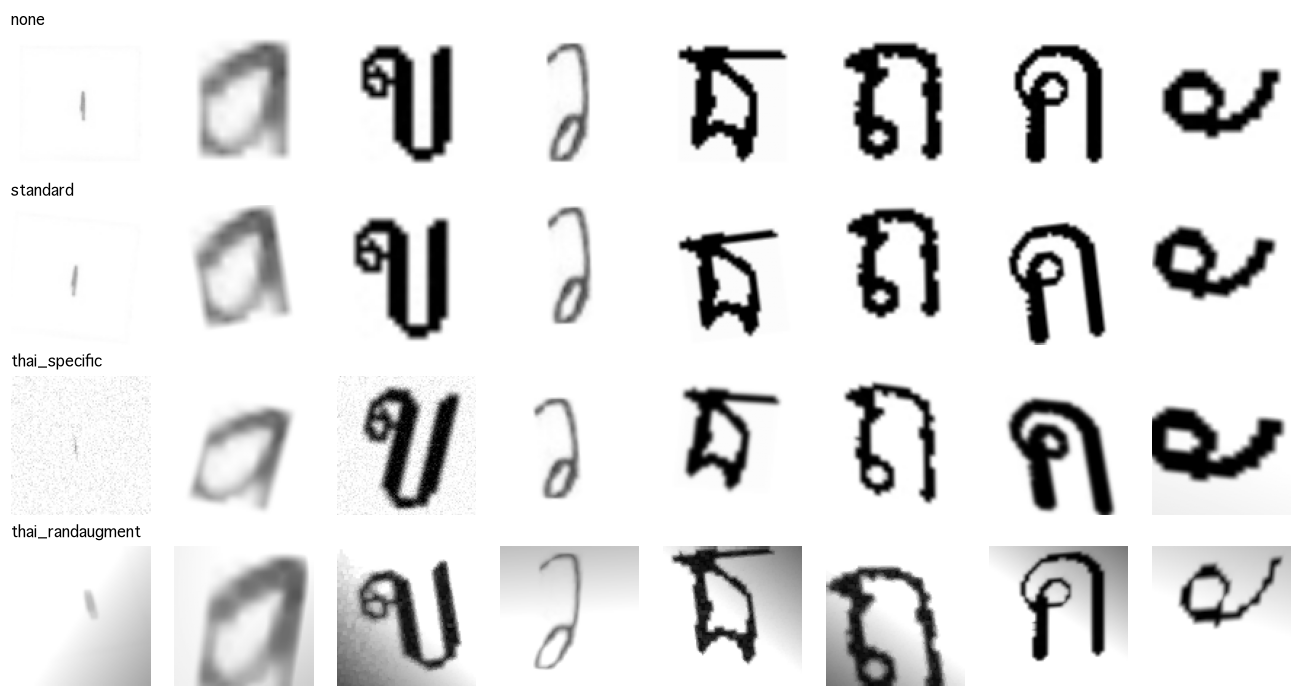

In [3]:
data = prepare(dict(cfg, limit_per_class=20))
device = get_device(cfg.get("device", "auto"))
ids = np.random.default_rng(0).choice(len(data.y), 8, replace=False)
batch = torch.from_numpy(data.x[ids]).to(device).float().div(255).unsqueeze(1)

fig, axes = plt.subplots(len(POLICIES), 8, figsize=(12, 1.6 * len(POLICIES)))
for r, name in enumerate(POLICIES):
    out = get_policy(name)(batch.clone()).cpu().numpy()[:, 0]
    for c in range(8):
        axes[r][c].imshow(out[c], cmap="gray", vmin=0, vmax=1); axes[r][c].axis("off")
    axes[r][0].set_title(name, loc="left", fontsize=10)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "figures" / "augmentation_examples.png", bbox_inches="tight")
plt.show()

## รันจริง

4 policy × ~10 epoch ใช้เวลาราว 2–3 ชั่วโมง ผลเขียนลง `experiments/augmentation/` และ
`results/tables/augmentation.csv`

In [4]:
data = prepare(cfg)
rows = run_augmentation(cfg, data)
rows

ใช้ cache research_cache_96.npz: 163155 รูป
  ตัดคลาสที่มีตัวอย่างน้อยกว่า 2: 163×1, 177×1, 208×1

=== augmentation: none ===
[mobilenet_v3_small | aug=none] train 49912 | val 6239 | 81 classes | 1.6M params | mps
    ep1 step 0/389 loss 4.5408
    ep1 step 200/389 loss 1.0011
  epoch 1 train_loss 1.6128 train_acc 0.7826 sec 46.1268 val_acc 0.7666
    ep2 step 0/389 loss 0.8768
    ep2 step 200/389 loss 0.8145
  epoch 2 train_loss 0.8220 train_acc 0.9858 sec 42.1635 val_acc 0.9862
    ep3 step 0/389 loss 0.8074
    ep3 step 200/389 loss 0.7802
  epoch 3 train_loss 0.7948 train_acc 0.9915 sec 42.0163 val_acc 0.9909
    ep4 step 0/389 loss 0.8171
    ep4 step 200/389 loss 0.7724
  epoch 4 train_loss 0.7844 train_acc 0.9933 sec 41.2693 val_acc 0.9923
    ep5 step 0/389 loss 0.7723
    ep5 step 200/389 loss 0.7661
  epoch 5 train_loss 0.7787 train_acc 0.9947 sec 41.5748 val_acc 0.9910
    ep6 step 0/389 loss 0.7654
    ep6 step 200/389 loss 0.7671
  epoch 6 train_loss 0.7746 train_acc 0.99

[{'augmentation': 'none',
  'accuracy': 0.9936,
  'macro_f1': 0.979,
  'best_epoch': 8},
 {'augmentation': 'standard',
  'accuracy': 0.9926,
  'macro_f1': 0.9783,
  'best_epoch': 8},
 {'augmentation': 'thai_specific',
  'accuracy': 0.9909,
  'macro_f1': 0.9814,
  'best_epoch': 8},
 {'augmentation': 'thai_randaugment',
  'accuracy': 0.9897,
  'macro_f1': 0.9774,
  'best_epoch': 10}]

## เทียบผล

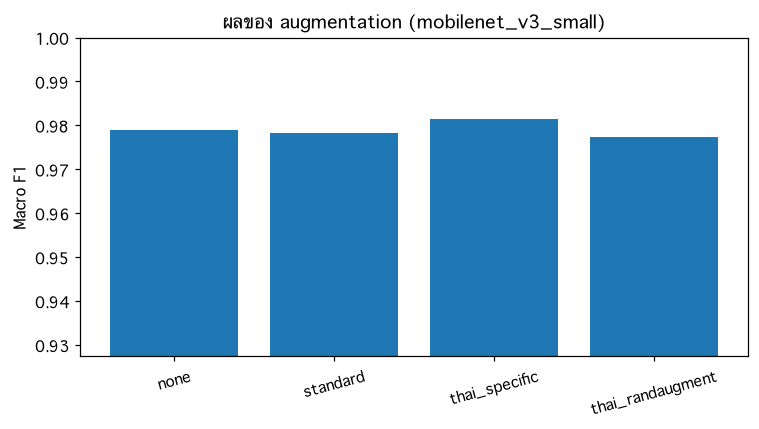

{'augmentation': 'none', 'accuracy': '0.9936', 'macro_f1': '0.979', 'best_epoch': '8'}
{'augmentation': 'standard', 'accuracy': '0.9926', 'macro_f1': '0.9783', 'best_epoch': '8'}
{'augmentation': 'thai_specific', 'accuracy': '0.9909', 'macro_f1': '0.9814', 'best_epoch': '8'}
{'augmentation': 'thai_randaugment', 'accuracy': '0.9897', 'macro_f1': '0.9774', 'best_epoch': '10'}


In [5]:
import csv
rows = list(csv.DictReader(open(RESULTS_DIR / "tables" / "augmentation.csv", encoding="utf-8")))
x = [r["augmentation"] for r in rows]
plt.figure(figsize=(7, 4))
plt.bar(x, [float(r["macro_f1"]) for r in rows])
plt.ylabel("Macro F1"); plt.title(f'ผลของ augmentation ({cfg["model"]})')
plt.xticks(rotation=15); plt.ylim(min(float(r["macro_f1"]) for r in rows) - 0.05, 1.0)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "figures" / "augmentation_comparison.png", bbox_inches="tight")
plt.show()
for r in rows:
    print(r)

### อ่านผลอย่างไร

ถ้า `thai_specific` ชนะ `standard` ไม่มาก ให้ดูที่ Experiment D ด้วย เพราะประโยชน์ของ augmentation
มักเห็นชัดตอนทดสอบ **ข้าม source** มากกว่าตอนทดสอบใน source เดียวกัน

เลือก policy ที่ดีที่สุดไปใส่ `augmentation:` ใน `configs/generalization.yaml`
แล้วไปที่ `04_hard_character_mining.ipynb`